* Análise de Performance de Jogadores – Temporada 2025/2026

 Dataset: Kaggle – Players Data 2025/2026

Este projeto tem como objetivo analisar o desempenho de jogadores da temporada 2025/2026, identificando padrões ofensivos e defensivos, comparando ligas e construindo um modelo simplificado de avaliação de performance.

Hipóteses exploratórias: 

– H1: KP (Key Passes) possui correlação positiva com G+A.

– H2: Existe faixa etária de pico ofensivo.

– H3: Ligas apresentam estilos distintos (ofensivo vs defensivo).

In [1]:
# Importando libs
import pandas as pd # manipulação e análse de dados
import matplotlib.pyplot as plt # visualização de dados
import seaborn as sns # visualização de dados

# pip install pandas matplotlib seaborn

* Carregando dados

In [3]:
# Filtrar colunas
colunas_desejadas = ["Player", "Nation", "Pos", "Squad", "Comp", "Age", "Gls", "Ast", "G+A", "Saves", "Tkl+Int", "KP" ]

# Ler dados de arquivo csv
df = pd.read_csv(r"data\players_data-2025_2026.csv", usecols=colunas_desejadas)
df.head()
df.info()
df.describe()
df.isnull().sum()

# Visualizar dados
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2433 entries, 0 to 2432
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   2433 non-null   object 
 1   Nation   2432 non-null   object 
 2   Pos      2433 non-null   object 
 3   Squad    2433 non-null   object 
 4   Comp     2433 non-null   object 
 5   Age      2431 non-null   float64
 6   Gls      2433 non-null   int64  
 7   Ast      2433 non-null   int64  
 8   G+A      2433 non-null   int64  
 9   KP       2433 non-null   int64  
 10  Tkl+Int  2433 non-null   int64  
 11  Saves    150 non-null    float64
dtypes: float64(2), int64(5), object(5)
memory usage: 228.2+ KB


,Player,Nation,Pos,Squad,Comp,Age,Gls,Ast,G+A,KP,Tkl+Int,Saves
0,Brenden Aaronson,us USA,"FW,MF",Leeds United,eng Premier League,25.0,4,3,7,19,40,NaN
1,Zach Abbott,eng ENG,DF,Nott'ham Forest,eng Premier League,19.0,0,0,0,0,1,NaN
2,Jones El-Abdellaoui,ma MAR,"FW,MF",Celta Vigo,es La Liga,20.0,2,0,2,3,2,NaN
3,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,2,0,2,8,35,NaN
4,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,32.0,0,0,0,6,13,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2428,Yanis Zouaoui,dz ALG,DF,Le Havre,fr Ligue 1,31.0,0,1,1,22,33,NaN
2429,Igor Zubeldia,es ESP,DF,Real Sociedad,es La Liga,28.0,0,1,1,5,32,NaN
2430,Martín Zubimendi,es ESP,MF,Arsenal,eng Premier League,26.0,3,1,4,15,63,NaN
2431,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,27.0,1,3,4,26,21,NaN


Análise 1 – Perfil das ligas

* Qual liga é mais ofensiva?

                         Gls       G+A
Comp                                  
de Bundesliga       1.015766  1.754505
eng Premier League  1.141988  1.898580
es La Liga          0.920388  1.568932
fr Ligue 1          0.893390  1.509595
it Serie A          0.873047  1.470703
Comp
it Serie A            1.608398
fr Ligue 1            1.648188
es La Liga            1.704854
de Bundesliga         1.893018
eng Premier League    2.091278
dtype: float64


(0.0, 2.415425963488844)

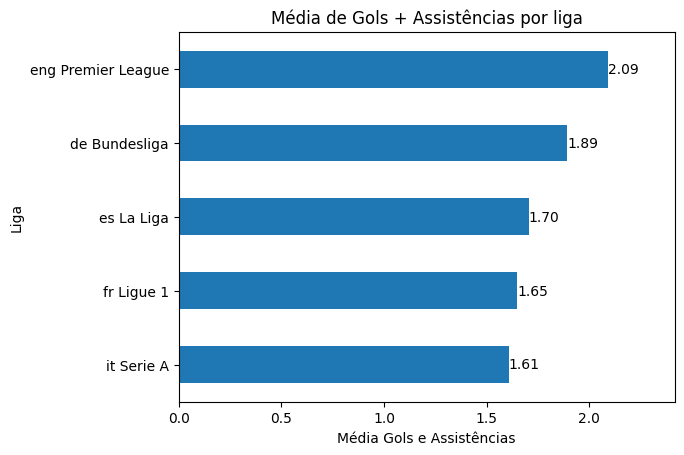

In [ ]:
# Média de Gls e G+A por liga
ofensive = df.groupby("Comp")[["Gls","G+A"]].mean()
print(ofensive)

media = (ofensive['Gls'] + ofensive['G+A'] / 2).sort_values(ascending=True)
print(media)

mean = ofensive


# Visualizar dados (gráfico de barras horizontal)
ax = media.plot.barh()
ax.set_title('Média de Gols + Assistências por liga')
ax.set_ylabel('Liga')
ax.set_xlabel('Média Gols e Assistências')
ax.bar_label(ax.containers[0], fmt='{:.2f}')
ax.set_xlim(0, ax.get_xlim()[1] * 1.1)


* Qual liga é mais “criadora”?

                          KP
Comp                        
de Bundesliga       6.290541
eng Premier League  7.494929
es La Liga          6.737864
fr Ligue 1          5.910448
it Serie A          6.943359
                          KP
Comp                        
eng Premier League  7.494929
it Serie A          6.943359
es La Liga          6.737864
de Bundesliga       6.290541
fr Ligue 1          5.910448


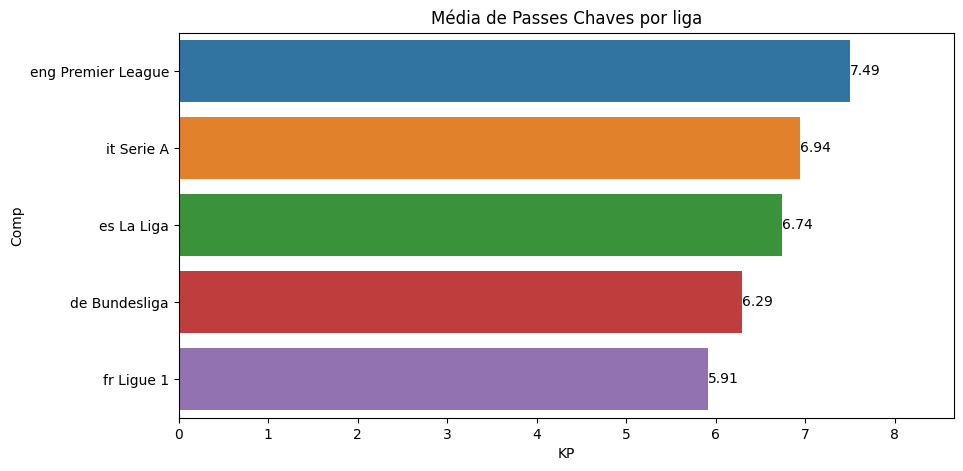

In [ ]:
# Média de KP por liga
keyPasses = df.groupby("Comp")[["KP"]].mean()
print(keyPasses)

media = keyPasses.sort_values(by='KP', ascending=False)
print(media)

# Visualizar dados (gráfico de barras horizontal)
plt.figure(figsize=(10,5))
plt.title('Média de Passes Chaves por liga')
plt.bar_label(ax.containers[0], fmt='{:.2f}')
sns.barplot(data=media, x="KP", y="Comp", hue="Comp")
plt.xlim(0, plt.xlim()[1] * 1.1)
plt.show()


*  Qual liga é mais jovem?

                          Age
Comp                         
de Bundesliga       25.412162
eng Premier League  25.511156
es La Liga          26.390291
fr Ligue 1          24.808102
it Serie A          26.127451
                          Age
Comp                         
es La Liga          26.390291
it Serie A          26.127451
eng Premier League  25.511156
de Bundesliga       25.412162
fr Ligue 1          24.808102


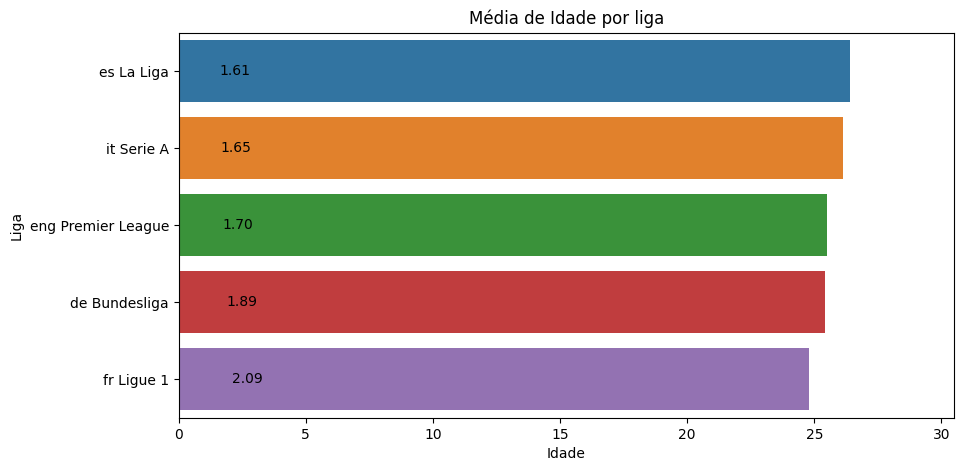

In [229]:
# Média de idade por liga
age = df.groupby("Comp")[["Age"]].mean()
print(age)

media = age.sort_values(by='Age', ascending=False)
print(media)

# Visualizar dados (gráfico de barras horizontal)
plt.figure(figsize=(10,5))
plt.title('Média de Idade por liga')
plt.xlabel('Idade')
plt.ylabel('Liga')
plt.bar_label(ax.containers[0], fmt='{:.2f}')
sns.barplot(data=media, x="Age", y="Comp", hue="Comp")
plt.xlim(0, plt.xlim()[1] * 1.1)
plt.show()
